In [1]:
# imports
import numpy as np
import importlib
np.set_printoptions(precision=2, suppress=False)
from numpy import array
import matplotlib.pyplot as plt
from pprint import pprint, pformat
from umap import UMAP
from hdbscan import HDBSCAN, prediction

import shot.bridge as dp
from szxxx.common.nb_tools import *
import szxxx.common.plotting as plot
import szxxx.common.tools as tools
import szxxx.common.hist_data as hd 
import szxxx.features.forecast as fc

import keanu.config as conf
from keanu.config import *
from keanu.common.common import *

# fc.Forecast.save(DATA,
#         data_window=30, profit_min=8e-4, panic_threshold=2e-4, step=1, verbose=True)

forecast = tools.load(
    'forecast;data_window-30profit_min-8.0panic_threshold-2.0', verbose=False)
DATA = hd.set_hist_data(conf)

In [2]:
# Forecast
md(f'''

    minimal profit[PIP]: {forecast.profit_min / PIP:.0}
    exemplary prediction: 
        {forecast.predictions[list(forecast.predictions.keys())[300]]}
    prediction format: 
        <timestamp>: [<advice>, <virtual profit>, <trans. time idx>, \\
                                    <panic idx>, <panic time idx>, <timestamp>]
''')

In [3]:
dataphora = dp.Bridge(
    timeshots=DATA, 
    monotonic_duration=10, 
    vertical_range={dp.Direction.BWD: 150, dp.Direction.FWD: 100},
    snapshot_size={dp.Direction.BWD: 12, dp.Direction.FWD: 10},  
    adversity=0.5, sltp=90)


Received 396364 timeshots
ASC decision points: 751 found
DSC decision points: 744 found


In [4]:
inputs, outputs, skipped = dataphora.generate_inputs_and_outputs()

Skipped 1 decision point(s) due to snapshot overflow


In [5]:
inputs[0]

(1740954060.0,
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 21)

In [6]:
features_plus = array([_[1] + [_[0]] for _ in inputs])
virtual_all = array([_[1] for _ in list(forecast.predictions.values())])
outputs = {_[0]: _[1] for _ in outputs}

In [7]:
virtual = []
advice = []
features = []
target = []
preds = forecast.predictions
for feat in features_plus:
    stamp = feat[-1]
    if (stamp in preds) and (stamp in outputs):
        pred = preds[stamp]
        features.append(feat[:-1])
        target.append(outputs[stamp])
        virtual.append(pred[1])
        advice.append(pred[0])

features = array(features)
target = array(target)
virtual = array(virtual)
advice = array(advice)

In [8]:
importlib.reload(plot)

<module 'szxxx.common.plotting' from 'C:\\Users\\stefa\\Documents\\workspaces\\szx81\\szxxx\\src\\szxxx\\common\\plotting.py'>

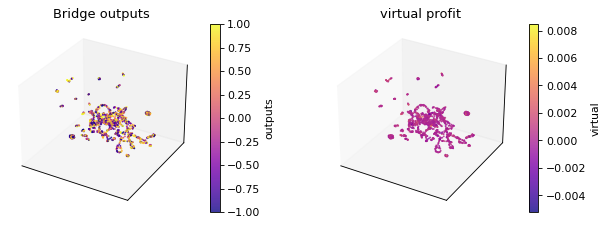

In [9]:
class ViewInput:
    def __init__(self, features, target, advice, 
                 n_neighbors=5, min_dist=0.9,):
        n_components = 3
        alpha = 1
        umap = UMAP(
                    n_neighbors=n_neighbors,
                    min_dist=min_dist,
                    n_components=n_components, 
                    metric='euclidean',
                    init='pca',
                    n_jobs=1,
                    random_state=42,
                    ).fit(features)
        umap_emb = umap.embedding_
        plot.plot_array(
            plots=[
                plot.ScatterCm(
                    X=umap_emb,
                    c=target,
                    cmap='plasma',
                    label='outputs',
                    s=0.5,
                    alpha=alpha,
                    title='Bridge outputs',
                    count=2000,
                    projection=n_components,
                ),
                plot.ScatterCm(
                    X=umap_emb,
                    c=virtual,
                    cmap='plasma',
                    label='virtual',
                    s=0.5,
                    alpha=alpha,
                    title='virtual profit',
                    count=2000,
                    projection=n_components,
                ),
            ],
            rows=1,
            clms=2,
            size=(8.5, 3),
        )
    def caption(self):
        md(f'''
**UMAP** discovers the topology of a given multidimensional vector set and reproduce it in a lower dimension. The accuracy of the process can be adjusted with the parameters `n_neighbors` and `min_dist`.
           
The consistency of the data distribution is a good prognostic. Still better if clusters are differently labeled - colored.
           
The figure above represent featuring of the `Bridge`. The titles and labels refer to the color labeling of the data

''')

vi = ViewInput(features, target, advice, n_neighbors=5, min_dist=0.9)
vi.caption()

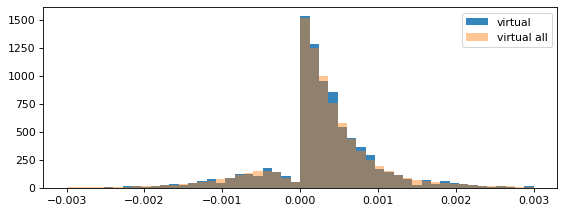

In [10]:
# virtual input vs all virtual histogram
def _(virtual):
    fig, axs = plot.fig_init('features', (1, 1), 3, width=8.5, dpi=78)
    axs = axs.flatten()
    alpha = 0.9
    
    axs[0].hist(virtual, 
                density=True, bins=50, range=(-0.003, 0.003),
                label=f'virtual', alpha=alpha)
    axs[0].hist(virtual_all, 
                density=True, bins=50, range=(-0.003, 0.003),
                label=f'virtual all', alpha=alpha / 2)    
    axs[0].legend()
      

    plt.show()
_(virtual)

In [11]:
from szxxx.features.features import FeaturesDto, Features
from szxxx.features.piecewise import PiecewiseDto, Piecewise
from szxxx.tokenizer.tokenizer import Tokenizer 

In [77]:

md('##`Piecewise` feature extractor')

In [ ]:

from szxxx.config import Config
Config('szx81')

features=tools.load(
        'piecewise;mean_len-15;seg_size-10;idx_step-1;', verbose=False)
tokenizer=Tokenizer(features, {
                Piecewise.TIME: (4, 'lambda x: np.log10(x + 1.)'), 
                Piecewise.VALUE: (8, None),
                Piecewise.SLOPE: (8, None),
                Piecewise.NOISE: (8, None),
                Piecewise.VOLUME: (8, 'lambda x: np.log10(x + 1.)'),
            }
)

In [ ]:
# 
segments = np.array(features.segments) # (858, 10, 6)
segments = np.random.permutation(segments)
features_mod = tokenizer.modify_features(segments.T)
features_norm = tokenizer.norm_features(features_mod).T

In [ ]:

profit_min = 8e-4
seq_len = -10
virtual = []
target = []
features = []
preds = forecast.predictions
for feat in features_norm[:4000]:
    stamp = feat[-1][-1]
    if stamp in preds:
        pred = preds[stamp]
        features.append(feat.T[:-1].T[seq_len:].flatten())
        v = pred[1]
        if v > profit_min:
            target.append(UP)
        elif -profit_min > v:
            target.append(DOWN)
        else:
            target.append(WAIT)
        virtual.append(v)
        
features = array(features)
features[np.isnan(features)] = 0
virtual = array(virtual)
target = array(target)

wait_mask = target == WAIT

features_wait = features[wait_mask]
cut = len(features[~wait_mask]) // 3
features_adj = np.concatenate((features[~wait_mask], features[wait_mask][:cut]))
virtual_adj = np.concatenate((virtual[~wait_mask], virtual[wait_mask][:cut]))
target_adj = np.concatenate((target[~wait_mask], target[wait_mask][:cut]))

In [91]:
# class ViewPiecewise
class FeatureUmap:
    def __init__(self, features, target, virtual, titles,
                 n_neighbors=5, min_dist=0.9,):
        n_components = 3
        alpha = 0.99
        s = 0.8
        umap = UMAP(
                    n_neighbors=n_neighbors,
                    min_dist=min_dist,
                    n_components=n_components, 
                    metric='euclidean',
                    init='pca',
                    n_jobs=1,
                    random_state=42,
                    ).fit(features)
        umap_emb = umap.embedding_
        plot.plot_array(
            plots=[
                plot.Scatter(
                    X=umap_emb,
                    c=target,
                    cmap='tab10',
                    label=DIR_MAP,
                    s=s,
                    alpha=alpha,
                    title=titles[0],
                    count=2000,
                    projection=n_components,
                ),
                plot.ScatterCm(
                    X=umap_emb,
                    c=virtual,
                    cmap='viridis',
                    label='virtual',
                    s=s,
                    alpha=alpha,
                    title=titles[1],
                    count=2000,
                    projection=n_components,
                ),
            ],
            rows=1,
            clms=2,
            size=(8.5, 5),
        )
    def caption(self):
        md(f'''
**UMAP** discovers the topology of a given multidimensional vector set and reproduce it in a lower dimension. The accuracy of the process can be adjusted with the parameters `n_neighbors` and `min_dist`.
           
The figure above represent featuring by the `Piecewise`. The titles and labels refer to the color labeling of the data
           
The population of the `WAIT` component is cut down in order to make the active cases visible.

''')

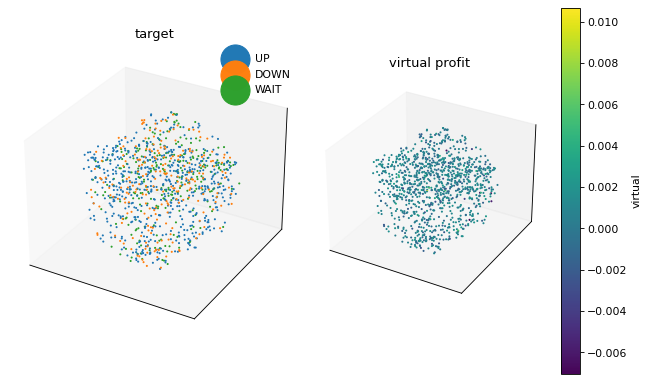

In [92]:
# ViewPiecewise
vi = FeatureUmap(features_adj, target_adj, virtual_adj, 
                   ('target', 'virtual profit'),
                   n_neighbors=10, min_dist=0.5)
vi.caption()